# Data Manipulation and More Feature Engineering

In [1]:
library(tidyverse)
dir = "../data/date-hour-soo-dest-"
od_2024 <- read_csv(paste(dir,"2024.csv", sep = ""), 
        col_names = c(
            "date", 
            "hour", 
            "origin",
            "destination",
            "ridership"
        ))
od_2023 <- read_csv(paste(dir,"2023.csv", sep = ""), 
        col_names = c(
            "date", 
            "hour", 
            "origin",
            "destination",
            "ridership"
        ))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 8939603 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): origin, destination
dbl  (2): hour, ridership
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 8690367 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2)

## Adding In Zeros

I'm going to try and use the `complete()` function from tidyverse to add in the zeros. Let's first try it with a toy example.

In [20]:
dat <- bind_rows(od_2023, od_2024)


In [3]:
set.seed(230)
test <- slice_sample(dat, n = 10)
test

date,hour,origin,destination,ridership
<date>,<dbl>,<chr>,<chr>,<dbl>
2023-06-18,23,UCTY,CIVC,1
2023-08-20,15,CIVC,ROCK,6
2024-11-07,14,BALB,DALY,10
2023-04-23,10,DELN,NBRK,4
2023-05-01,21,FRMT,ROCK,1
2024-07-16,17,EMBR,COLS,33
2023-03-30,11,RICH,MONT,4
2023-07-13,7,MLPT,MONT,10
2024-09-18,14,PITT,12TH,4


In [4]:
complete(test, date, hour, origin, destination, fill = list(ridership = 0)) |> count(ridership)

ridership,n
<dbl>,<int>
0,6390
1,2
2,1
4,3
6,1
10,2
33,1


This added 7280 rows to the dataset. I imagine that is because most combinations of date, hour, origin, and destination did not exist in my toy example, let's try it with a larger subset.

In [5]:
test <- dat |> 
            filter(month(date) == 6)
head(test)

date,hour,origin,destination,ridership
<date>,<dbl>,<chr>,<chr>,<dbl>
2023-06-01,0,12TH,12TH,3
2023-06-01,0,12TH,16TH,1
2023-06-01,0,12TH,BALB,1
2023-06-01,0,12TH,CIVC,1
2023-06-01,0,12TH,CONC,1
2023-06-01,0,12TH,MLBR,1


In [6]:
complete(test, date, hour, origin, destination, fill = list(ridership = 0))

date,hour,origin,destination,ridership
<date>,<dbl>,<chr>,<chr>,<dbl>
2023-06-01,0,12TH,12TH,3
2023-06-01,0,12TH,16TH,1
2023-06-01,0,12TH,19TH,0
2023-06-01,0,12TH,24TH,0
2023-06-01,0,12TH,ANTC,0
2023-06-01,0,12TH,ASHB,0
2023-06-01,0,12TH,BALB,1
2023-06-01,0,12TH,BAYF,0
2023-06-01,0,12TH,BERY,0


In [7]:
complete(test, date, hour, origin, destination, fill = list(ridership = 0)) |>
    count(ridership) |>
    head(5)

ridership,n
<dbl>,<int>
0,2147268
1,501021
2,257648
3,155353
4,104013


Ok, this is still somewhat problematic, let's see what happens when I plot the distribution of ridership for a specific OD pair.

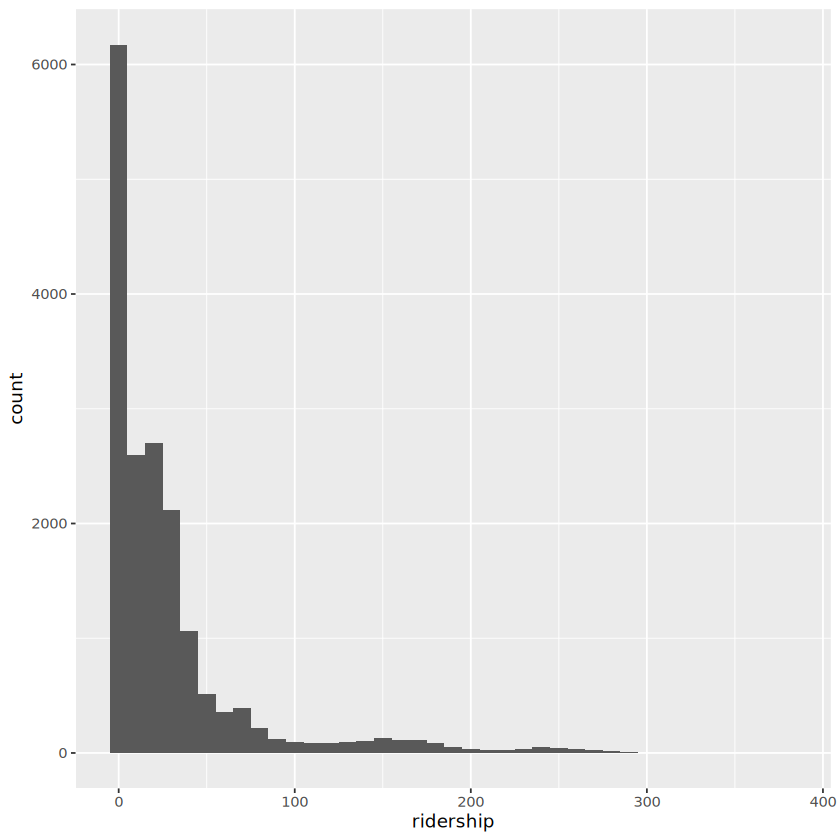

In [8]:
dat |> 
    filter((origin == "WOAK") &
                (destination == "EMBR")) |>
    complete(date, hour, origin, destination, fill = list(ridership = 0)) |>
    select(ridership) |>
    ggplot(aes(x = ridership)) + 
        geom_histogram(binwidth = 10)


Ok, what about an obviously less popular pair?

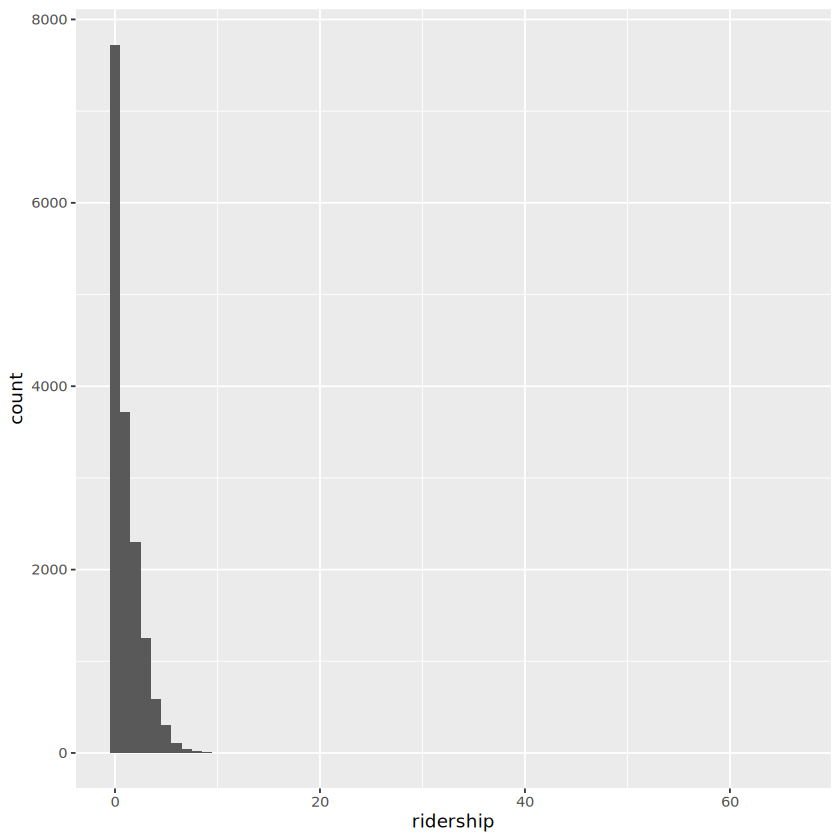

In [9]:
dat |> 
    filter((origin == "CAST") &
                (destination == "BAYF")) |>
    complete(date, hour, origin, destination, fill = list(ridership = 0)) |>
    select(ridership) |>
    ggplot(aes(x = ridership)) + 
        geom_histogram(binwidth = 1)

In [10]:
dat |> 
    filter((origin == "CAST") &
                (destination == "BAYF")) |>
    complete(date, hour, origin, destination, fill = list(ridership = 0)) |>
    count(ridership)

ridership,n
<dbl>,<int>
0,7726
1,3723
2,2298
3,1251
4,587
5,305
6,113
7,45
8,21


Note: don't forget to change the binwidth for plots for different OD pairs. The two pairs above did not have comparable ridership, the plot for CAST to BAYF looked very strange with `binwidth = 30`.

Let's pull the trigger and complete the whole dataset, then see what the size is.

In [11]:
format(object.size(dat), units = "GB")

[1] "0.7 Gb"

In [12]:
dat_complete <- dat |>
                    complete(date, hour, origin, destination, fill = list(ridership = 0))
format(object.size(dat_complete), units = "GB")

[1] "1.6 Gb"

In [13]:
dat_complete |> count(ridership) |> slice_head(n = 5)

ridership,n
<dbl>,<int>
0,26230030
1,6110069
2,3123328
3,1881246
4,1258768


In [14]:
dat_complete |> count(ridership) |> slice_tail(n = 10)

ridership,n
<dbl>,<int>
532,1
543,1
557,1
562,1
590,1
591,1
599,1
673,1
678,1


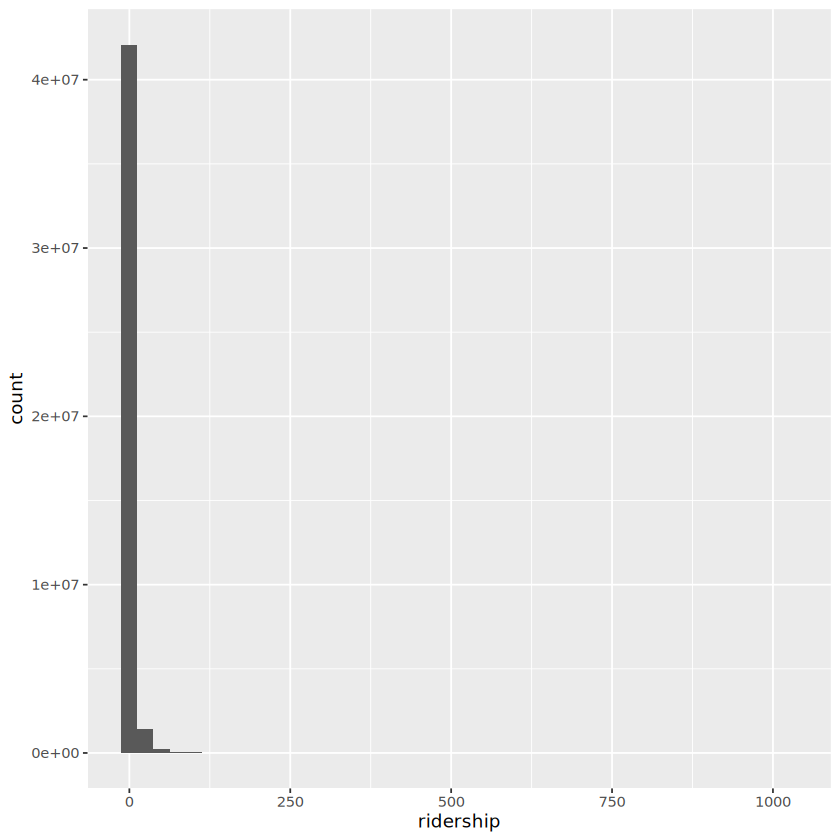

In [15]:
dat_complete |>
    ggplot(aes(x = ridership)) + 
    geom_histogram(binwidth = 25)

The conclusion is that we should definitely implement some kind of filtering first before adding back in the zeros.

## Adding Zeros After Filtering

Just a reminder, the current schedule is

| Day | Hours |
|-----|-------|
| Weekday | 5:00 AM - 12:00 AM |
| Saturday | 6:00 AM - 12:00 AM |
| Sunday | 8:00 AM - 12:00 AM |

Let's do some filtering by schedule

In [21]:
dat_filtered <- dat |>
                    mutate(day = case_when(wday(date) %in% seq(2, 6) ~ "weekday",
                                            wday(date) == 1 ~ "sunday",
                                            wday(date) == 7 ~ "saturday")) |>
                    filter((day == "weekday") & !(hour %in% c(3, 4)) |
                                    (day == "saturday") & !(hour %in% c(3, 4, 5)) | 
                                    (day == "sunday") & !(hour %in% c(3, 4, 5, 6, 7)))


Now, let's check for seasonality and add a categorical variable to account for that

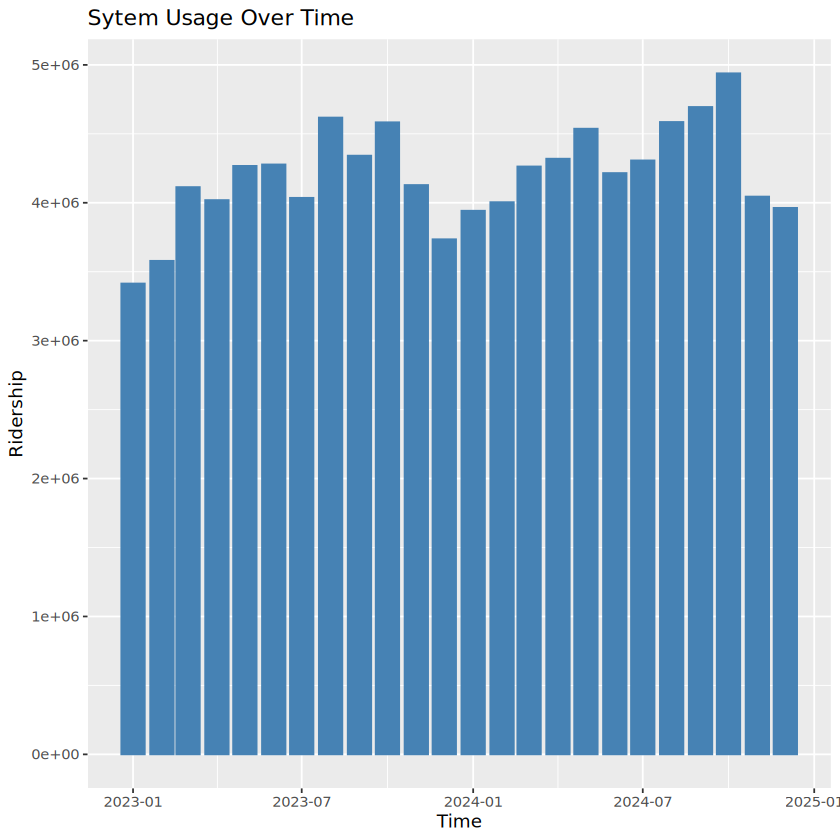

In [22]:
dat_filtered |> 
    mutate(month_year = floor_date(date, unit = "month")) |>
    group_by(month_year) |>
    summarize(riders = sum(ridership)) |>
    ggplot(aes(x = month_year, y = riders)) + 
        geom_col(fill = "steelblue", color = "steelblue") +
        labs(title = "Sytem Usage Over Time",
            x = "Time",
            y = "Ridership")

It think we can stick with traditional seasons
| season | months |
|--------|--------|
| Winter | 12 - 2 |
| Spring | 3 - 5 |
| Summer | 6 - 8 |
| Fall | 9 - 11 | 

In [34]:
dat_filtered <- dat_filtered |> mutate(season = case_when(month(date) %in% c(12, 1, 2) ~ "winter",
                                            month(date) %in% seq(3, 5) ~ "spring",
                                            month(date) %in% seq(6 - 8) ~ "summer",
                                            month(date) %in% seq(9, 11) ~ "fall"))
head(dat_filtered)

date,hour,origin,destination,ridership,day,season
<date>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>
2023-01-01,0,12TH,12TH,1,sunday,winter
2023-01-01,0,12TH,16TH,1,sunday,winter
2023-01-01,0,12TH,19TH,2,sunday,winter
2023-01-01,0,12TH,24TH,3,sunday,winter
2023-01-01,0,12TH,ASHB,2,sunday,winter
2023-01-01,0,12TH,CONC,1,sunday,winter


I want to see if I can drop OD pairs with a really small amount of observations.

In [ ]:
dat_filtered |>
  group_by(origin, destination) |>
  summarize(ridership_total = sum(ridership), .groups = "drop") |>
  arrange(desc(ridership_total)) |>
  slice_head(n = 10)

origin,destination,ridership_total
<chr>,<chr>,<dbl>
POWL,BALB,552173
WOAK,EMBR,514823
POWL,24TH,500480
BALB,POWL,496626
SFIA,POWL,470890
EMBR,WOAK,439423
24TH,POWL,432269
POWL,DALY,428796
DUBL,EMBR,424922


In [ ]:
dat_filtered |>
  group_by(origin, destination) |>
  summarize(ridership_total = sum(ridership), .groups = "drop") |>
  arrange(ridership_total) |>
  slice_head(n = 10)

origin,destination,ridership_total
<chr>,<chr>,<dbl>
WDUB,NCON,110
WDUB,LAFY,214
NCON,WDUB,218
CAST,NCON,231
PCTR,CAST,237
LAFY,WDUB,252
NCON,CAST,252
BERY,MLBR,254
CAST,PCTR,264


This doesn't seem to be small enough. I know that's subjective. Let's move on to using complete on this filtered data.

In [ ]:
dat_complete <- dat_filtered |>
  select(-c(day, season)) |>
  complete(date, hour, origin, destination, fill = list(ridership = 0))

format(object.size(dat_complete), units = "GB")

[1] "1.5 Gb"

In [36]:
dat_complete |> count(ridership)

ridership,n
<dbl>,<int>
0,22601356
1,6093746
2,3118870
3,1879255
4,1257673
5,896006
6,666057
7,509737
8,404286


## Feature Engineering on Data with Zeros

Let's see how our ridership statistics are affected by the filtering and completing.

In [ ]:
dat_complete <- dat_complete |> 
  mutate(day = case_when(wday(date) %in% seq(2, 6) ~ "weekday",
                         wday(date) == 1 ~ "sunday",
                         wday(date) == 7 ~ "saturday"),
         season = case_when(month(date) %in% c(12, 1, 2) ~ "winter",
                            month(date) %in% seq(3, 5) ~ "spring",
                            month(date) %in% seq(6 - 8) ~ "summer",
                            month(date) %in% seq(9, 11) ~ "fall"))

In [ ]:
dat_complete |>
  group_by(season, day) |>
  summarize(median = median(ridership),
            mean = mean(ridership),
            sd = sd(ridership))

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by season and day.
ℹ Output is grouped by season.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(season, day))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


season,day,median,mean,sd
<chr>,<chr>,<dbl>,<dbl>,<dbl>
fall,saturday,0,1.804222,5.178943
fall,sunday,0,1.376041,4.131662
fall,weekday,0,3.102736,9.372830
spring,saturday,0,1.631530,4.540172
spring,sunday,0,1.221890,3.640343
spring,weekday,0,2.953209,9.047995
winter,saturday,0,1.533459,4.390000
winter,sunday,0,1.107491,3.340812
winter,weekday,0,2.661743,8.396267


In [39]:
dat_complete |> 
    summarize(median = median(ridership), mean = mean(ridership), sd = sd(ridership))

median,mean,sd
<dbl>,<dbl>,<dbl>
0,2.510417,7.997438


This means that we clearly have overdispersion and we should use a zero inflated model or negative binomial model